# Stage 1: Risk Reversal Surface VAE (INR 隐式表达架构)

从多日期的 RR 真实观测点中学习 2 维潜在表示，采用 Deep Sets 编码 + Implicit Decoder，
坐标轴严格使用 log_moneyness (ln(K/S))，供后续定价模型作为特征使用。

| 输入 | 输出 |
|------|------|
| `full_option_trading_data.csv`（项目根目录） | `rr_surface_vae_train_only.pt`（VAE 模型） |
| 训练集 2401–2411 的 RR 观测点 | 2 维 latent z，供 stage 4、5 使用 |

**近期改动**：
- **Beta 系数**：`vae_loss = recon_loss + beta * kl_loss`，`beta` 默认 0.01，可调以平衡重建与 latent 正则
- **Decoder 深度**：4 层全连接 `[128, 128, 64, 32]` + LeakyReLU，增强对非线性情绪结构的捕捉
- **RR_value 标准化**：`std` 设下限 0.05，避免数值过小导致重建误差占比过低、引发维度坍缩

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == 'Notebooks' else Path.cwd()))

from RiskReversalSurfaceVAE import RiskReversalSurfaceVAE
import numpy as np
import matplotlib.pyplot as plt
import random

plt.rcParams['font.family'] = ['Arial Unicode MS']


def set_seed(seed: int):
    """固定随机种子，保证 VAE 训练与 latent 提取可复现"""
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False
    except ImportError:
        pass

In [3]:
# 初始化 INR-VAE：2 维 latent，直接使用真实观测点（不做插值）
# beta=0.01 控制 KL 权重；decoder 默认 4 层 [128,128,64,32] + LeakyReLU
vae = RiskReversalSurfaceVAE(latent_dim=2, beta=0.01)

# 从 CSV 准备数据集：收集每日真实 (T, log_moneyness, rr_value) 观测点
data_list, dates = vae.prepare_dataset(csv_path="full_option_trading_data.csv")
print(f"样本数: {len(dates)}, 首日观测点数: {data_list[0].shape[0]}")

样本数: 427, 首日观测点数: 10


In [4]:
# 样本数据描述：一个实例对应一份数据输入
desc = vae.describe_samples()
for k, v in desc.items():
    if isinstance(v, dict):
        print(f"{k}:")
        for kk, vv in v.items():
            print(f"  {kk}: {vv:.4f}" if isinstance(vv, float) else f"  {kk}: {vv}")
    else:
        print(f"{k}: {v}")

数据源: full_option_trading_data.csv
样本数（交易日）: 427
总观测点数: 20779
日均观测点数: 48.66276346604216
日期范围: 2023-03-20 ~ 2024-12-19
RR 值统计:
  均值: 0.0144
  标准差: 0.1876
  最小值: -4.6843
  最大值: 3.2965
time_to_expire 范围: [0.0027, 1.0082]
log_moneyness 范围: [-0.4010, 0.3693]


## 随机种子与 Latent 分布质量说明

**好的 latent 分布应具备**：
- **聚类结构**：相似市场情绪（如恐慌/贪婪）的日期在 latent 空间聚集，不同 regime 可分
- **平滑过渡**：相邻日期的 latent 不应剧烈跳跃，时间序列上应有连续性
- **覆盖合理**：点云不过度集中在一角，也不过度分散成噪声，有一定方差便于区分
- **可解释性**：若 z[0] 与市场情绪、z[1] 与期限结构相关，则更利于后续定价

**固定种子**：VAE 的权重初始化与 reparameterization 采样依赖随机数，固定种子可复现结果，便于对比不同超参或架构。

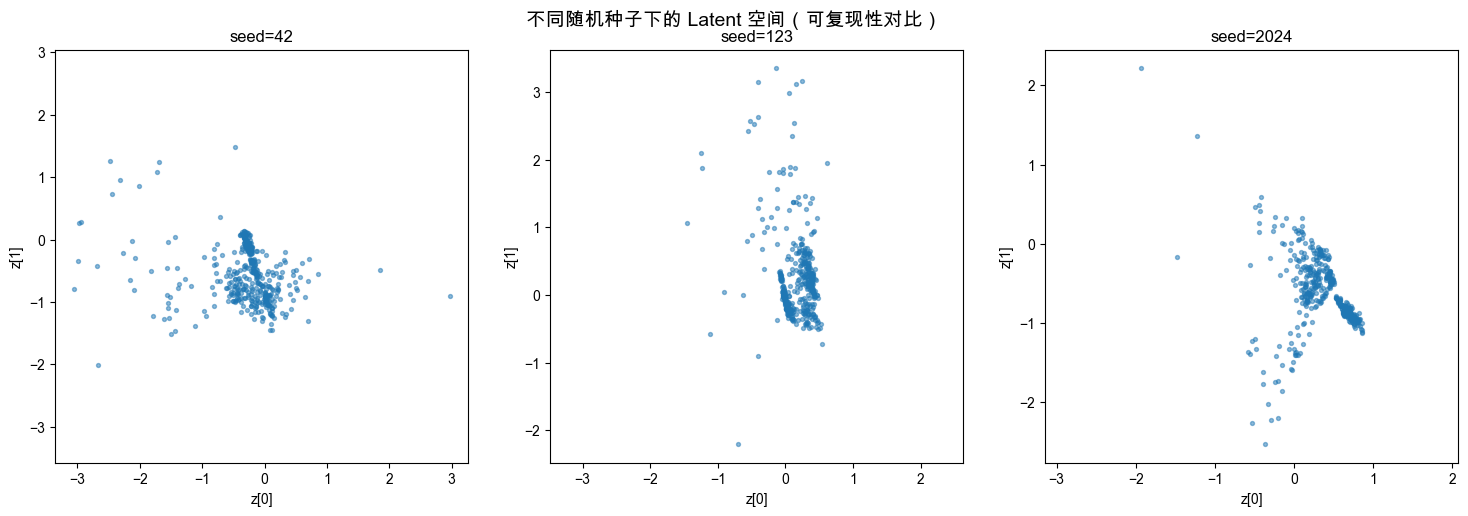

In [5]:
# 选取三个随机种子，分别训练并展示 latent 提取效果
SEEDS = [42, 123, 2024]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, seed in enumerate(SEEDS):
    set_seed(seed)
    vae = RiskReversalSurfaceVAE(latent_dim=2, beta=0.01)  # 默认 4 层 Decoder + LeakyReLU
    vae.fit(data_list, epochs=80, lr=1e-3, verbose=False)
    z = vae.encode(data_list)
    axes[i].scatter(z[:, 0], z[:, 1], alpha=0.5, s=8)
    axes[i].set_xlabel("z[0]")
    axes[i].set_ylabel("z[1]")
    axes[i].set_title(f"seed={seed}")
    axes[i].set_aspect("equal")
    axes[i].set_box_aspect(1)  # 固定子图为正方形

plt.suptitle("不同随机种子下的 Latent 空间（可复现性对比）", fontsize=14)
plt.tight_layout()
plt.show()

# vae 已为最后一个 seed 的模型，供后续 save/decode 使用

In [6]:
# 训练已在上一 cell 完成（3-seed 对比），vae 为 seed=2024 的模型

In [7]:
# 编码：获取 2 维 latent，用于后续定价特征（当前 vae 为 seed=2024）
z = vae.encode(data_list)
print(f"Latent shape: {z.shape}")

Latent shape: (427, 2)


In [8]:
# 保存模型（供后续定价时加载）
vae.save_model("rr_surface_vae_inr.pt")
print("模型已保存到 rr_surface_vae_inr.pt")

模型已保存到 rr_surface_vae_inr.pt


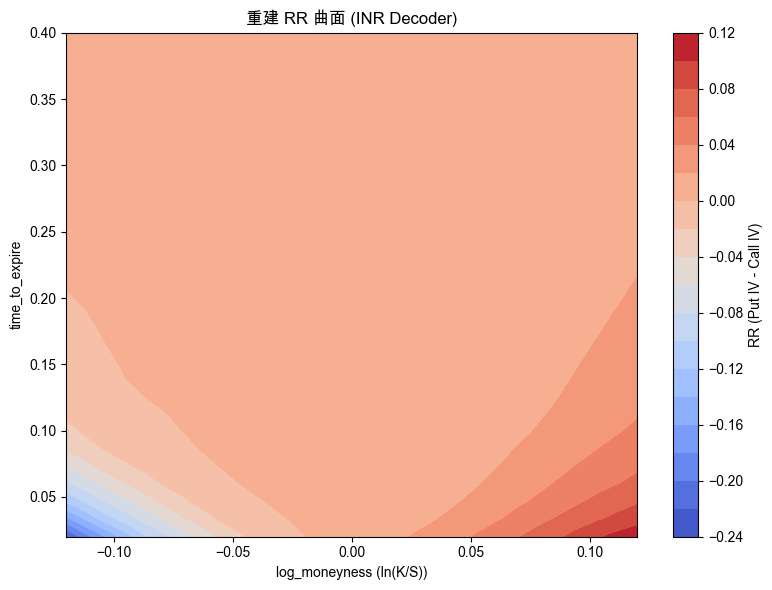

In [9]:
# 解码 + 曲面可视化：decode(z, T_grid, m_grid) 支持任意查询网格
z0 = vae.encode(data_list[0])
T_grid = np.linspace(0.02, 0.4, 30)
m_grid = np.linspace(-0.12, 0.12, 30)
rr_surface = vae.decode(z0, T_grid, m_grid)

# 2D 等高线图
fig, ax = plt.subplots(figsize=(8, 6))
cf = ax.contourf(m_grid, T_grid, rr_surface, levels=20, cmap="coolwarm")
ax.set_xlabel("log_moneyness (ln(K/S))")
ax.set_ylabel("time_to_expire")
ax.set_title("重建 RR 曲面 (INR Decoder)")
plt.colorbar(cf, ax=ax, label="RR (Put IV - Call IV)")
plt.tight_layout()
plt.show()

In [10]:
# 推理示例：加载模型后对单日观测点提取 latent 特征（beta/decoder 从 .pt 恢复）
vae_loaded = RiskReversalSurfaceVAE(latent_dim=2)
vae_loaded.load_model("rr_surface_vae_inr.pt")
z_single = vae_loaded.encode(data_list[0])
print(f"单日 latent 特征: {z_single}")

单日 latent 特征: [ 0.8522415 -0.9974952]
